# Station visualisation

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import numpy as np
import cartopy.io.shapereader as shapereader
from matplotlib.patches import Rectangle

In [2]:
# custom modules
import sys
import json
sys.path.append("../..")  # noqa
from load import data_dir
from bcm4rcm.utils.areal_plots import regional_rectangle

## LTM stations (Open data)

In [3]:
ltm_df = pd.read_csv('LTM_HKH.csv', names=['name', 'lat', 'lon', 'type'], header=0, index_col=False).dropna()

/tmp/ipykernel_1141692/1849554548.py:1: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  ltm_df = pd.read_csv('LTM_HKH.csv', names=['name', 'lat', 'lon', 'type'], header=0, index_col=False).dropna()


In [4]:
ltm_df

,name,lat,lon,type
0,Langtang,28.10,85.50,ALL
1,Tanggula,33.00,92.00,ALL
2,Dokriani,30.80,78.80,GLAC
3,Hidden Valley,28.80,83.50,GLAC + PF
4,Khumbu,27.70,86.90,GLAC
5,Chhota Shigri,32.20,77.50,GLAC
6,Tuotuo He,34.00,92.00,HYD + PF
7,South Pullu,34.25,77.62,PF
8,Trambau,27.90,86.50,GLAC
9,Hulu,38.10,99.80,ALL


## GHCN stations

In [5]:
col_widths = [12, 9, 10, 8, 30, 8, 8]
col_names= ['id', 'lat', 'lon', 'elevation', 'name', 'gsn_flag', 'wmo_id']
ghcnd_df = pd.read_fwf('ghcnd-stations_hma.txt', widths=col_widths, header=None, names=col_names)

## Station visualistion

In [6]:
# HKH region
hkh_region_path = data_dir + "Shapefiles/hkh/outline.shp"
hkh_region_shape = shapereader.Reader(hkh_region_path)
hkh_region_globe = ccrs.Globe(semimajor_axis=6377276.345, inverse_flattening=300.8017)
hkh_region = ccrs.PlateCarree()

In [7]:
# Filter station dataframe to only include stations within the HKH region

from shapely.geometry import Point, shape

for rec in hkh_region_shape.records():
    hkh_shape = shape(rec.geometry)
    ghcnd_df['geometry'] = ghcnd_df.apply(lambda row: Point(row['lon'], row['lat']), axis=1)

hkh_ghcnd_df = ghcnd_df[ghcnd_df['geometry'].apply(lambda x: hkh_shape.contains(x))]
print(f"Number of GHCND stations within HKH region: {len(hkh_ghcnd_df)}")

Number of GHCND stations within HKH region: 309


In [8]:
hkh_ghcnd_df 

,id,lat,lon,elevation,name,gsn_flag,wmo_id,geometry
0,AF000040930,35.317,69.017,3366.0,NORTH-SALANG,GSN,40930.0,POINT (69.017 35.317)
2,AFM00040948,34.566,69.212,1791.3,KABUL INTL,NaN,40948.0,POINT (69.212 34.566)
50,CHM00052602,38.833,93.383,2771.0,LENGHU,NaN,52602.0,POINT (93.383 38.833)
52,CHM00052713,37.850,95.367,3174.0,DA-QAIDAM,NaN,52713.0,POINT (95.367 37.85)
53,CHM00052754,37.333,100.133,3302.0,GANGCA,NaN,52754.0,POINT (100.133 37.333)
...,...,...,...,...,...,...,...,...
4470,PKM00041739,26.955,64.133,1002.5,PANJGUR,NaN,41739.0,POINT (64.133 26.955)
4471,PKM00041744,27.833,66.633,1232.0,KHUZDAR,NaN,41744.0,POINT (66.633 27.833)
4524,TI000038930,36.900,68.000,319.0,AJVADZ,NaN,38930.0,POINT (68 36.9)
4536,TI000038954,37.500,71.500,2077.0,KHOROG,GSN,38954.0,POINT (71.5 37.5)


In [9]:
# Create country column for GHCND stations using id prefix

prefix_dict = {
    'IN': 'India',
    'CH': 'China',
    'NP': 'Nepal',
    'AF': 'Afghanistan',
    'PK': 'Pakistan',
    'TI': 'Tajikistan',
    'KG': 'Kyrgyzstan',
    'UZ': 'Uzbekistan',
    'KZ': 'Kazakhstan'
}
hkh_ghcnd_df.loc[:, 'country'] = hkh_ghcnd_df.loc[:, 'id'].str[:2].map(prefix_dict)
ghcnd_df.loc[:, 'country'] = ghcnd_df.loc[:, 'id'].str[:2].map(prefix_dict)
print(ghcnd_df['country'].value_counts())

country
India          3807
Kazakhstan      329
China           228
Uzbekistan       78
Kyrgyzstan       73
Tajikistan       62
Pakistan         35
Afghanistan       4
Nepal             2
Name: count, dtype: int64


/tmp/ipykernel_1141692/3534550683.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hkh_ghcnd_df.loc[:, 'country'] = hkh_ghcnd_df.loc[:, 'id'].str[:2].map(prefix_dict)


In [10]:
ghcnd_df[(ghcnd_df['country']).isna()]

,id,lat,lon,elevation,name,gsn_flag,wmo_id,geometry,country


In [11]:
colour_map = {
    'India': 'red',
    'China': 'blue',
    'Nepal': 'green',
    'Afghanistan': 'yellow',
    'Pakistan': 'purple',
    'Tajikistan': 'orange',
    'Uzbekistan': 'cyan',
    'Kyrgyzstan': 'magenta',
    'Kazakhstan': 'brown'
}

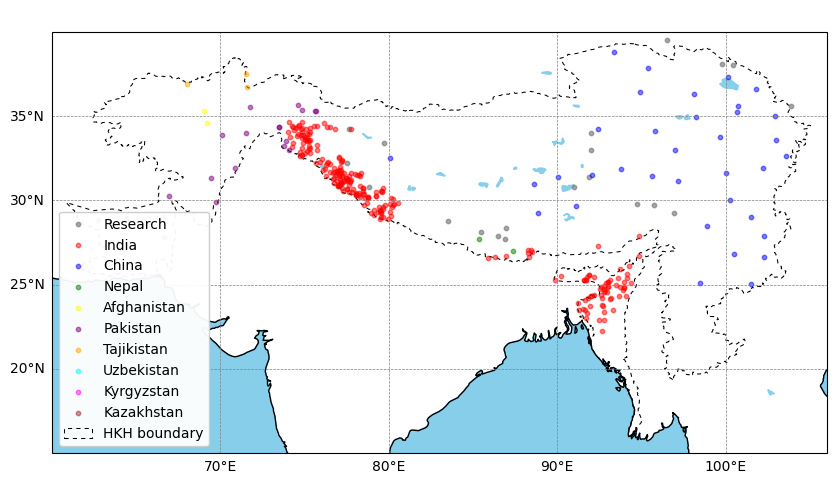

In [12]:
fig, ax1 = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Cartopy features
ocean_50m = cf.NaturalEarthFeature(
    "physical", "ocean", "50m", edgecolor="face", facecolor="skyblue"
)
lakes_50m = cf.NaturalEarthFeature(
    "physical", "lakes", "50m", edgecolor="skyblue", facecolor="skyblue"
)
# river_50m = cf.NaturalEarthFeature("physical", "rivers_lake_centerlines", "50m", edgecolor="skyblue", facecolor="None")
ax1.add_feature(ocean_50m, zorder=-10)
ax1.add_feature(lakes_50m, label="lakes", zorder=-9)

ltm = ax1.scatter(ltm_df['lon'], ltm_df['lat'], color='Grey', label='Research', transform=ccrs.PlateCarree(), 
            s=10, alpha=0.7)

country_handles = []
for country, color in colour_map.items():
    country_stations = hkh_ghcnd_df[hkh_ghcnd_df['country'] == country]
    stations = ax1.scatter(country_stations['lon'], country_stations['lat'], 
                c=color, transform=ccrs.PlateCarree(), label=country, 
                s=10, alpha=0.5)
    country_handles.append(stations)

ax1.add_feature(cf.COASTLINE)
ax1.set_extent([60, 110, 20, 40], crs=ccrs.PlateCarree())

# Mountain boundaries
for rec in hkh_region_shape.records():
    ax1.add_geometries(
        [rec.geometry],
        hkh_region,
        edgecolor="black",
        facecolor="None",
        linestyle=(0, (4, 4)),
        linewidth=0.75,
        zorder=-7,
    )

# Grid
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", color="gray")
gl.top_labels = False
gl.right_labels = False
ax1.set_ylabel(" ")
ax1.set_xlabel(" ")
ax1.set_title(" ")
ax1.set_extent([60, 106, 15, 40], crs=ccrs.PlateCarree())


hkh = Rectangle(
    (0, 0),
    1,
    1,
    fc="None",
    edgecolor="black",
    linewidth=0.75,
    linestyle=(0, (4, 4)),
    label="HKH boundary",
)

ax1.legend(
    handles=[ltm] + country_handles + [hkh], loc="lower left", framealpha=0.95
)

# rasterize negative zorder
ax1.set_rasterization_zorder(0)

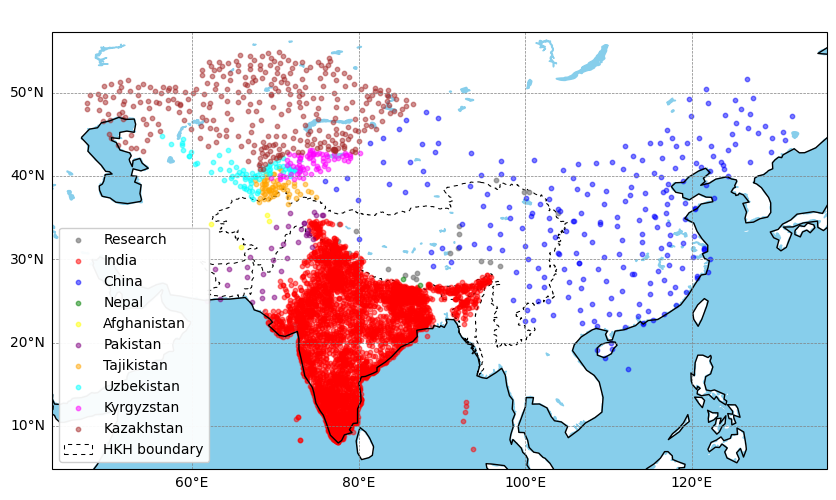

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Cartopy features
ocean_50m = cf.NaturalEarthFeature(
    "physical", "ocean", "50m", edgecolor="face", facecolor="skyblue"
)
lakes_50m = cf.NaturalEarthFeature(
    "physical", "lakes", "50m", edgecolor="skyblue", facecolor="skyblue"
)
# river_50m = cf.NaturalEarthFeature("physical", "rivers_lake_centerlines", "50m", edgecolor="skyblue", facecolor="None")
ax1.add_feature(ocean_50m, zorder=-10)
ax1.add_feature(lakes_50m, label="lakes", zorder=-9)

ltm = ax1.scatter(ltm_df['lon'], ltm_df['lat'], color='Grey', label='Research', transform=ccrs.PlateCarree(), 
            s=10, alpha=0.7)

country_handles = []
for country, color in colour_map.items():
    country_stations = ghcnd_df[ghcnd_df['country'] == country]
    stations = ax1.scatter(country_stations['lon'], country_stations['lat'], 
                c=color, transform=ccrs.PlateCarree(), label=country, 
                s=10, alpha=0.5)
    country_handles.append(stations)

ax1.add_feature(cf.COASTLINE)
#ax1.set_extent([60, 110, 20, 40], crs=ccrs.PlateCarree())

# Mountain boundaries
for rec in hkh_region_shape.records():
    ax1.add_geometries(
        [rec.geometry],
        hkh_region,
        edgecolor="black",
        facecolor="None",
        linestyle=(0, (4, 4)),
        linewidth=0.75,
        zorder=-7,
    )

# Grid
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", color="gray")
gl.top_labels = False
gl.right_labels = False
ax1.set_ylabel(" ")
ax1.set_xlabel(" ")
ax1.set_title(" ")
#ax1.set_extent([60, 105, 10, 40], crs=ccrs.PlateCarree())


hkh = Rectangle(
    (0, 0),
    1,
    1,
    fc="None",
    edgecolor="black",
    linewidth=0.75,
    linestyle=(0, (4, 4)),
    label="HKH boundary",
)

ax1.legend(
    handles=[ltm] + country_handles + [hkh], loc="lower left", framealpha=0.95
)

# rasterize negative zorder
ax1.set_rasterization_zorder(0)

## Masks

### Centralised station mask

In [14]:
combined_stations = pd.concat([ltm_df, ghcnd_df], ignore_index=True)

In [15]:
# Create 2D histogram of station locations using APHRODITE grid
res = 0.25
lon_bins = np.arange(60, 105+res, res)
lat_bins = np.arange(20, 40+res, res)


In [16]:
lon_bins.shape, lat_bins.shape

((181,), (81,))

In [17]:
density, lon_edges, lat_edges = np.histogram2d(
    combined_stations['lon'], combined_stations['lat'], 
    bins=[lon_bins, lat_bins]
)

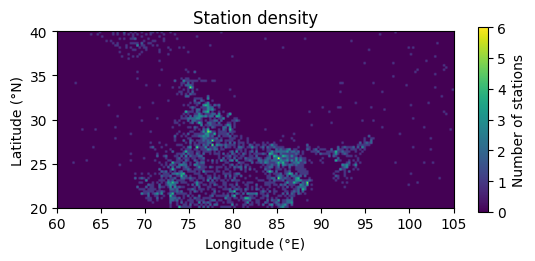

In [18]:
plt.imshow(density.T, origin='lower', extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]])
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Station density')
plt.colorbar(label='Number of stations', shrink=0.5)
plt.show()

In [19]:
mask = np.where(density > 0, 1, 0).T
mask.shape

(80, 180)

In [20]:
# Effective sample density
mask.mean()

np.float64(0.12451388888888888)

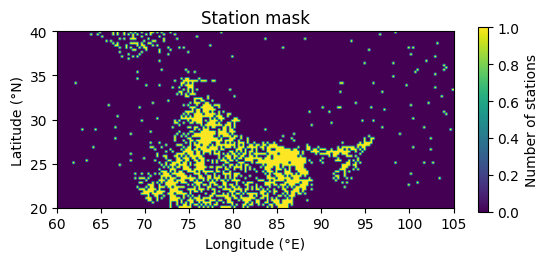

In [30]:
plt.imshow(mask, origin='lower', extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]], )
plt.xlabel('Longitude (°E)')
plt.ylabel('Latitude (°N)')
plt.title('Station mask')
plt.colorbar(label='Number of stations', shrink=0.5)
plt.show()

### Out mask (water-land)

In [23]:
#  Use APHRODITE sea-land mask
ds = xr.open_dataset("/data/hpcdata/users/kenzi22/data/APHRODITE/daily/APHRO_MA_025deg_V1901.1998.nc").sel(lat=slice(20, 40), lon=slice(60, 105))
out_mask = np.where(np.isnan(ds.precip[0].values), 0, 1)

In [32]:
np.save("masks/out_mask.npy", out_mask)

In [24]:
# Combine with station mask
combined_mask = out_mask + mask

In [38]:
final_combined_mask = np.where(combined_mask > 1, 1, 0)

In [41]:
np.save("masks/centralised_mask.npy", final_combined_mask)

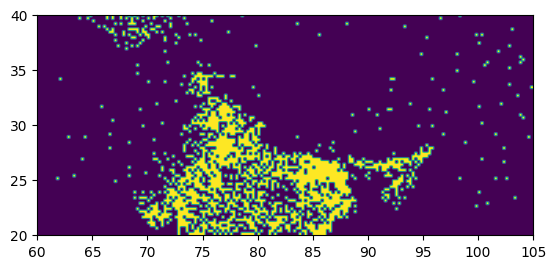

In [40]:
plt.imshow(final_combined_mask, origin='lower', extent=[lon_bins[0], lon_bins[-1], lat_bins[0], lat_bins[-1]])

### Country input masks

In [42]:
for country in ghcnd_df['country'].unique():
    country_stations = combined_stations[(combined_stations['country'] == country) | (combined_stations['country'].isna())]
    
    # create 2D density histogram for country
    density, lon_edges, lat_edges = np.histogram2d(
        country_stations['lon'], country_stations['lat'], 
        bins=[lon_bins, lat_bins]
    )

    # create mask for country
    country_mask = np.where(density > 0, 1, 0).T
    combined_mask = out_mask + country_mask
    final_combined_mask = np.where(combined_mask > 1, 1, 0)
    
    print(country)

    np.save(f"masks/{country.lower()}_mask.npy", final_combined_mask)

Afghanistan
China
India
Kyrgyzstan
Kazakhstan
Nepal
Pakistan
Tajikistan
Uzbekistan


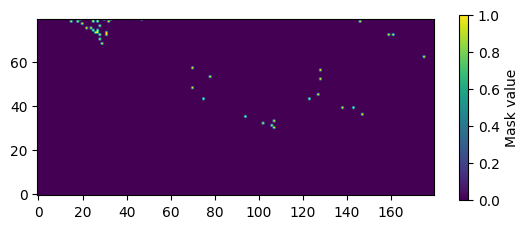

In [43]:
plt.imshow(country_mask, origin="lower")
plt.colorbar(label='Mask value', shrink=0.5)